# CLIP Score

The introduction and implementations of CLIP Score.

Written by yuanjk0921@outlook.com

Updated on March 4, 2025

**Contents**
- CLIP Score
- PyTorch Implementations

**References**
- [**CLIPScore: A Reference-free Evaluation Metric for Image Captioning** *(EMNLP 2021)*](https://arxiv.org/pdf/2104.08718): The paper which proposes the CLIP Score.

## CLIP Score

CLIP Score is a reference-free metric focusing on **semantic alignment** for *text-to-image generation* or *image captioning* evaluation.

[CLIP](http://proceedings.mlr.press/v139/radford21a/radford21a.pdf) is a cross-modal retrieval model trained on 400M (image, caption) pairs through contrastive learning. 

CLIP Score employs the embeddings of the ViT-B/32 version of CLIP with embedding dimension of 512.

CLIP Score calculates the cosine similarity of text embeddings $\mathbf{c}$ of the input prompt and image embeddings $\mathbf{v}$ of the input image.

$$\text{CLIP-S}(\mathbf{c},\mathbf{v})=\omega*\max(\cos(\mathbf{c},\mathbf{v}),0).$$

$\omega$ is usually set to 1, while it is sometimes set to 2.5 in some works.

## PyTorch Implementations

In [ ]:
## --------------------------------------------------------------------------------
## Load model
## --------------------------------------------------------------------------------
import clip
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_path = f"CLIP/ViT-B-32.pt"
model, image_preprocess = clip.load(name=model_path, device=device)
print(f"=> Finish loading model")

=> Finish loading model


In [ ]:
## --------------------------------------------------------------------------------
## Prepare data
## --------------------------------------------------------------------------------
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, image_paths, prompts, image_size):
        self.image_paths = image_paths
        self.prompts = prompts
        self.transform = transforms.Compose([
            transforms.Resize(
                image_size, interpolation=transforms.InterpolationMode.BICUBIC,
                antialias=True,
            ),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        file_path = self.image_paths[index]
        image = self.transform(Image.open(file_path))
        prompt = self.prompts[index]
        return image, prompt, file_path

image_paths = ["0.png"] * 8
image_paths = image_paths + ["random_noise.png"] * 8

## Save a noise image
noise = np.random.randint(0, 256, (3, 224, 224), dtype=np.uint8)
image = Image.fromarray(noise, mode='RGB')
image.save("random_noise.png")

prompts = [
    "green",
    "red",
    "teacher",
    "bowl",
    "a blue bowl",
    "a green bowl",
    "a green bench and a blue bowl",
    "a green apple and a blue bowl"
] * 2

dataset = ImageDataset(image_paths=image_paths, prompts=prompts, image_size=model.visual.input_resolution)
dataloader = DataLoader(dataset=dataset, batch_size=8, shuffle=False)

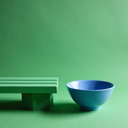

=> prompt: green, CLIP Score: 0.25927734375
=> prompt: red, CLIP Score: 0.193115234375
=> prompt: teacher, CLIP Score: 0.202392578125
=> prompt: bowl, CLIP Score: 0.276123046875
=> prompt: a blue bowl, CLIP Score: 0.30810546875
=> prompt: a green bowl, CLIP Score: 0.30859375
=> prompt: a green bench and a blue bowl, CLIP Score: 0.351318359375
=> prompt: a green apple and a blue bowl, CLIP Score: 0.330322265625


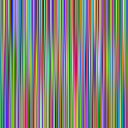

=> prompt: green, CLIP Score: 0.240478515625
=> prompt: red, CLIP Score: 0.223876953125
=> prompt: teacher, CLIP Score: 0.1978759765625
=> prompt: bowl, CLIP Score: 0.222900390625
=> prompt: a blue bowl, CLIP Score: 0.2259521484375
=> prompt: a green bowl, CLIP Score: 0.2109375
=> prompt: a green bench and a blue bowl, CLIP Score: 0.204833984375
=> prompt: a green apple and a blue bowl, CLIP Score: 0.213134765625


In [4]:
## --------------------------------------------------------------------------------
## Evaluate
## --------------------------------------------------------------------------------
import torch.nn.functional as F

for idx, (images, prompts, file_paths) in enumerate(dataloader):
    images_input = images.to(device=device)
    ## Tokenize prompts
    prompts_input = clip.tokenize(prompts, truncate=True).to(device=device)

    ## Embed images and prompts
    image_embed = model.encode_image(images_input)
    prompt_embed = model.encode_text(prompts_input)

    ## Get score
    scores = F.cosine_similarity(image_embed, prompt_embed)
    scores = scores.detach().cpu().numpy().tolist()

    ## Show results
    image = Image.open(file_paths[0]).resize((128, 128))
    display(image)
    for prompt, score in zip(prompts, scores):
        print(f"=> prompt: {prompt}, CLIP Score: {score}")

**Observations:**

- CLIP <font color=red>can identify</font> objects/colors, especially using prompts with <font color=red>only one word</font>.
- CLIP is <font color=red>not sensitive</font> to prompts with <font color=red>more than one words</font>.
- Only <font color=red>noise</font> can achieve CLIP score of <font color=red>above 0.2</font>.